In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, GridSearchCV, cross_val_score, cross_validate
import os
import glob
from scipy.stats import norm
import math
import random

In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error 


T_0 = pd.read_excel('2053-y.xlsx')
T=np.array(T_0)
#from sklearn import preprocessing  
#min_max_scaler = preprocessing.MinMaxScaler() 
#T=T_minMax = min_max_scaler.fit_transform(T)
#T=T.ravel()

print(T)  
print(len(T))

[[1]
 [1]
 [0]
 ...
 [0]
 [0]
 [0]]
2053


In [3]:
#读入特征    1000种描述符数据 
X=pd.read_excel('CDK + CDK extended + Substructure + Substructure count.xlsx')
X=np.array(X) 
#min_max_scaler = preprocessing.MinMaxScaler() 
#X=X_minMax = min_max_scaler.fit_transform(X)
print(X)
print(len(X[0]))
print(len(X))

[[ 0  0  0 ...  0  0  7]
 [ 0  0  0 ...  0  0  3]
 [ 0  0  0 ...  0  0 30]
 ...
 [ 0  0  0 ...  0  0  7]
 [ 0  0  0 ...  0  0  7]
 [ 0  0  0 ...  0  0  7]]
2662
2053


In [4]:

# FAK 1 -8

In [5]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.100,random_state=90)

In [6]:
from sklearn.metrics import accuracy_score,precision_score,f1_score
import lightgbm as lgbm

clf=lgbm.LGBMClassifier(boosting_type='gbdt',colsample_bytree=1.0,feature_fraction=0.8,bagging_fraction=0.8,num_leaves=20,min_child_samples=50,max_depth=-1,
                        learning_rate=0.05,n_estimators=200, n_jobs=-1)
clf.fit(X_train,T_train)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LGBMClassifier(bagging_fraction=0.8, feature_fraction=0.8, learning_rate=0.05,
               min_child_samples=50, n_estimators=200, num_leaves=20)

In [7]:
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
plt.style.use('ggplot')
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

regressor = lgb.LGBMRegressor(n_estimators=400, n_jobs=-1)
regressor.fit(X_train,T_train)
lgb.LGBMRegressor(boosting_type='gbdt', class_weight=0.5, colsample_bytree=1.0,
       importance_type='split', learning_rate=0.05, max_depth=4,
       min_child_samples=50, min_child_weight=0.001, min_split_gain=0.0,
       n_estimators=200, n_jobs=-1, num_leaves=20,random_state=90, reg_alpha=0.01, reg_lambda=0.1, silent=True,
       subsample=1.0, subsample_for_bin=200000, subsample_freq=0)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LGBMRegressor(class_weight=0.5, learning_rate=0.05, max_depth=4,
              min_child_samples=50, n_estimators=200, num_leaves=20,
              random_state=90, reg_alpha=0.01, reg_lambda=0.1)

In [8]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#from sklearn.externals import joblib
from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[100,  13],
       [ 17,  76]])

In [9]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8547    0.8850    0.8696       113
           1     0.8539    0.8172    0.8352        93

    accuracy                         0.8544       206
   macro avg     0.8543    0.8511    0.8524       206
weighted avg     0.8544    0.8544    0.8540       206



In [10]:
f1=f1_score(T_test,T_pred,average='micro')
print("the f1 score: %.3f"%f1)

the f1 score: 0.854


In [10]:
# ===== 全部指标：独立测试集结果（和你的 F1 逻辑完全一致）=====
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix

# 测试集预测
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# 独立测试集指标
f1 = f1_score(T_test, y_pred, average='micro')
roc_auc = roc_auc_score(T_test, y_pred_proba)
pr_auc = average_precision_score(T_test, y_pred_proba)
mcc = matthews_corrcoef(T_test, y_pred)

tn, fp, fn, tp = confusion_matrix(T_test, y_pred).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# 输出（全部是独立测试集结果）
print("the f1 score: %.3f" % f1)
print("the ROC-AUC score: %.3f" % roc_auc)
print("the PR-AUC score: %.3f" % pr_auc)
print("the MCC score: %.3f" % mcc)
print("the Sensitivity: %.3f" % sensitivity)
print("the Specificity: %.3f" % specificity)

the f1 score: 0.854
the ROC-AUC score: 0.933
the PR-AUC score: 0.931
the MCC score: 0.705
the Sensitivity: 0.817
the Specificity: 0.885


<Figure size 1000x1000 with 0 Axes>

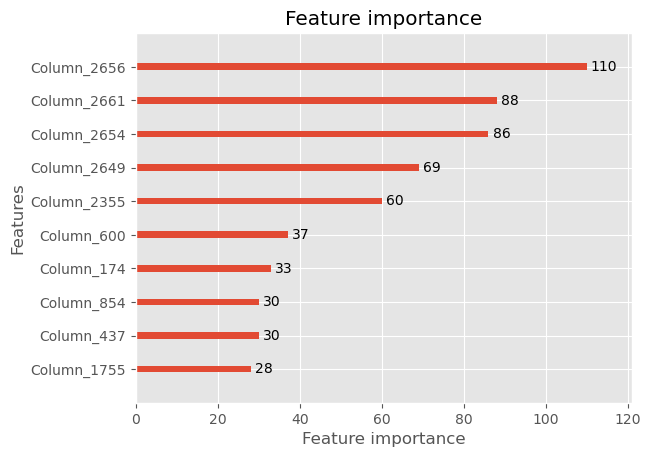

In [11]:
from lightgbm import plot_importance
# 显示重要特征
fig = plt.figure(figsize=(10,10))
plot_importance(clf,max_num_features=10)
plt.show()


In [12]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[942,  12],
       [ 29, 864]])

In [13]:
print (classification_report(T_train, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9701    0.9874    0.9787       954
           1     0.9863    0.9675    0.9768       893

    accuracy                         0.9778      1847
   macro avg     0.9782    0.9775    0.9778      1847
weighted avg     0.9780    0.9778    0.9778      1847



In [ ]:
# 十倍交叉验证

In [ ]:

from sklearn.model_selection import cross_validate

clf = lgbm.LGBMClassifier(boosting_type='gbdt', colsample_bytree=1.0, feature_fraction=0.8, bagging_fraction=0.8, num_leaves=20, 
                          min_child_samples=50, max_depth=-1, learning_rate=0.05, n_estimators=200)
cv = 10  # 十倍交叉验证的折数
scoring = ['accuracy', 'precision_macro', 'f1_macro']  # 评估指标


In [16]:
scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean()
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

print(f'Mean Accuracy (Test): {mean_accuracy:.4f} ± {std_accuracy:.4f}')
print(f'Mean Precision (Test): {mean_precision:.4f} ± {std_precision:.4f}')
print(f'Mean F1 Score (Test): {mean_f1:.4f} ± {std_f1:.4f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}')
print(f'Mean Precision (Train): {mean_train_precision:.4f} ± {std_train_precision:.4f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.4f} ± {std_train_f1:.4f}')


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


...

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
Mean Accuracy (Test): 0.8673 ± 0.0287
Mean Precision (Test): 0.8679 ± 0.0290
Mean F1 Score (Test): 0.8671 ± 0.0288
Mean Accuracy (Train): 0.9814 ± 0.0018
Mean Precision (Train): 0.9817 ± 0.0018
Mean F1 Score (Train): 0.9813 ± 0.0018


In [14]:
from sklearn.model_selection import cross_validate
import lightgbm as lgbm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, matthews_corrcoef, confusion_matrix
from sklearn.calibration import calibration_curve

# --------------------- 自定义指标 ---------------------
def sensitivity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# --------------------- 你原来的代码 完全不变 ---------------------
clf = lgbm.LGBMClassifier(boosting_type='gbdt', colsample_bytree=1.0, feature_fraction=0.8, bagging_fraction=0.8, num_leaves=20, 
                          min_child_samples=50, max_depth=-1, learning_rate=0.05, n_estimators=200)
cv = 10  # 十倍交叉验证的折数

# --------------------- 评分指标（全部加上：MCC 已加入） ---------------------
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',                # 新增
    'pr_auc': 'average_precision',       # 新增
    'mcc': make_scorer(matthews_corrcoef), # 新增 MCC
    'sensitivity': make_scorer(sensitivity), # 新增
    'specificity': make_scorer(specificity)  # 新增
}

scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

# --------------------- 你原来的指标 完全不变 ---------------------
mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean()
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

# --------------------- 新增指标的均值和方差 ---------------------
mean_roc_auc = scores['test_roc_auc'].mean()
mean_pr_auc = scores['test_pr_auc'].mean()
mean_mcc = scores['test_mcc'].mean()  # MCC
mean_sensitivity = scores['test_sensitivity'].mean()
mean_specificity = scores['test_specificity'].mean()

std_roc_auc = scores['test_roc_auc'].std()
std_pr_auc = scores['test_pr_auc'].std()
std_mcc = scores['test_mcc'].std()  # MCC
std_sensitivity = scores['test_sensitivity'].std()
std_specificity = scores['test_specificity'].std()

# --------------------- 输出原来的内容 ---------------------
print("==============================================================")
print("                       原有指标")
print("==============================================================")
print(f'Mean Accuracy (Test): {mean_accuracy:.4f} ± {std_accuracy:.4f}')
print(f'Mean Precision (Test): {mean_precision:.4f} ± {std_precision:.4f}')
print(f'Mean F1 Score (Test): {mean_f1:.4f} ± {std_f1:.4f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}')
print(f'Mean Precision (Train): {mean_train_precision:.4f} ± {std_train_precision:.4f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.4f} ± {std_train_f1:.4f}')

# --------------------- 输出新增指标（含 MCC） ---------------------
print("\n==============================================================")
print("                   新增指标（含 MCC）")
print("==============================================================")
print(f'Mean ROC-AUC (Test)    : {mean_roc_auc:.4f} ± {std_roc_auc:.4f}')
print(f'Mean PR-AUC (Test)     : {mean_pr_auc:.4f} ± {std_pr_auc:.4f}')
print(f'Mean MCC (Test)        : {mean_mcc:.4f} ± {std_mcc:.4f}')  # MCC输出
print(f'Mean Sensitivity (Test): {mean_sensitivity:.4f} ± {std_sensitivity:.4f}')
print(f'Mean Specificity (Test): {mean_specificity:.4f} ± {std_specificity:.4f}')
print("==============================================================")

# ===================== ✅ 修复部分：训练模型 + 预测概率 =====================
clf.fit(X_train, T_train)  # 训练模型
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # 预测概率

# ===================== 绘制校准曲线 =====================
prob_true, prob_pred = calibration_curve(T_test, y_pred_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label="Model Calibration")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

# 保存图片
plt.savefig("calibration_curve-lightGBM.png", dpi=300, bbox_inches="tight")
plt.close()

# 保存数据
calib_df = pd.DataFrame({
    "predicted_prob": prob_pred,
    "true_prob": prob_true
})
calib_df.to_csv("calibration_data-lightGBM.csv", index=False)

print("✅ 已保存：")
print("1. 校准曲线图片 → calibration_curve-lightGBM.png")
print("2. 校准数据文件 → calibration_data-lightGBM.csv")

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
                       原有指标
Mean Accuracy (Test): 0.8673 ± 0.0287
Mean Precision (Test): 0.8679 ± 0.0290
Mean F1 Score (Test): 0.8671 ± 0.0288
Mean Accuracy (Train): 0.9814 ± 0.0018
Mean Precision (Train): 0.9817 ± 0.0018
Mean F1 Score (Train): 0.9813 ± 0.0018

                   新增指标（含 MCC）
Mean ROC-AUC (Test)    : 0.9367 ± 0.0143
Mean PR-AUC (Test)     : 0.9335 ± 0.0172
Mean MCC (Test)        : 0.7350 ± 0.0581
Mean Sensitivity (Test): 0.8589 ± 0.0444
Mean Specificity (Test): 0.8752 ± 0.0265
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


✅ 已保存：
1. 校准曲线图片 → calibration_curve-lightGBM.png
2. 校准数据文件 → calibration_data-lightGBM.csv


In [15]:
#读入特征    描述符数据 
Z=pd.read_excel('CDK + CDK extended + Substructure + Substructure count（2015-2024）.xlsx')
Z=np.array(Z)
from sklearn import preprocessing  
#min_max_scaler = preprocessing.MinMaxScaler() 
#Z=Z_minMax = min_max_scaler.fit_transform(Z)
print(Z)
print(len(Z[0]))
print(len(Z))

[[ 1  0  0 ...  0  0  6]
 [ 0  0  0 ...  0  0  1]
 [ 0  0  0 ...  0  0  8]
 ...
 [ 0  0  0 ...  0  0  6]
 [ 0  0  0 ...  0  0 13]
 [ 0  0  0 ...  0  0  8]]
2662
200


In [16]:
Z_predict = clf.predict(Z)
print(Z_predict)

[0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [17]:
Z_predict = clf.predict(Z)
df=pd.DataFrame(Z_predict)
df.to_csv("2015-2024.新.csv",index=False,header=False)

In [18]:
Z_predict = clf.predict_proba(Z)
print(Z_predict)

[[5.07122416e-01 4.92877584e-01]
 [5.01118028e-01 4.98881972e-01]
 [5.59208200e-02 9.44079180e-01]
 [8.11465189e-03 9.91885348e-01]
 [5.47633645e-03 9.94523664e-01]
 [2.68806229e-02 9.73119377e-01]
 [3.54296765e-02 9.64570323e-01]
 [7.38152391e-02 9.26184761e-01]
 [5.95537739e-01 4.04462261e-01]
 [4.70206761e-02 9.52979324e-01]
 [5.36944240e-02 9.46305576e-01]
 [2.11016625e-02 9.78898337e-01]
 [1.17320061e-02 9.88267994e-01]
 [2.21451685e-03 9.97785483e-01]
 [1.83141598e-02 9.81685840e-01]
 [7.49122018e-03 9.92508780e-01]
 [6.61493825e-03 9.93385062e-01]
 [4.80667239e-02 9.51933276e-01]
 [2.25382851e-02 9.77461715e-01]
 [6.80662580e-02 9.31933742e-01]
 [1.48435658e-01 8.51564342e-01]
 [9.76200122e-01 2.37998776e-02]
 [2.60531653e-02 9.73946835e-01]
 [1.48526039e-02 9.85147396e-01]
 [1.39506689e-02 9.86049331e-01]
 [1.50302257e-02 9.84969774e-01]
 [4.87086634e-03 9.95129134e-01]
 [4.68870951e-02 9.53112905e-01]
 [1.21384066e-02 9.87861593e-01]
 [1.37201351e-02 9.86279865e-01]
 [2.305123

In [19]:
Z_predict = clf.predict_proba(Z)
df=pd.DataFrame(Z_predict)
df.to_csv("2015-2024.新0.csv",index=False,header=False)

In [15]:
#随机划分

In [16]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.1,random_state=90)

In [17]:
from sklearn.svm import SVC  # Support Vector Classifier
clf = SVC(kernel='linear') # 线性核函数
clf.fit(X_train,T_train)
SVC(C=1, cache_size=2000, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='linear', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, cache_size=2000, gamma='auto_deprecated', kernel='linear')

In [15]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
#from sklearn.externals import joblib
from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[106,   7],
       [ 28,  65]])

In [16]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.7910    0.9381    0.8583       113
           1     0.9028    0.6989    0.7879        93

    accuracy                         0.8301       206
   macro avg     0.8469    0.8185    0.8231       206
weighted avg     0.8415    0.8301    0.8265       206



In [17]:
f1=f1_score(T_test,T_pred,average='micro')
print("the f1 score: %.3f"%f1)

the f1 score: 0.830


In [14]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='liblinear',multi_class='ovr', C = 10, verbose =10, max_iter=600)
clf.fit(X_train, T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibLinear]iter  1 act 5.435e+03 pre 4.779e+03 delta 7.952e-01 f 1.280e+04 |g| 4.444e+04 CG   6
cg reaches trust region boundary
iter  2 act 1.777e+03 pre 1.474e+03 delta 1.119e+00 f 7.368e+03 |g| 1.480e+04 CG   6
cg reaches trust region boundary
iter  3 act 1.164e+03 pre 1.015e+03 delta 1.656e+00 f 5.591e+03 |g| 7.380e+03 CG   5
cg reaches trust region boundary
iter  4 act 9.738e+02 pre 8.715e+02 delta 2.205e+00 f 4.427e+03 |g| 3.586e+03 CG   7
cg reaches trust region boundary
iter  5 act 7.833e+02 pre 6.910e+02 delta 2.753e+00 f 3.454e+03 |g| 1.538e+03 CG   8
cg reaches trust region boundary
iter  6 act 6.475e+02 pre 5.680e+02 delta 3.447e+00 f 2.670e+03 |g| 1.214e+03 CG  10
cg reaches trust region boundary
iter  7 act 5.139e+02 pre 4.570e+02 delta 4.251e+00 f 2.023e+03 |g| 1.454e+03 CG  12
cg reaches trust region boundary
iter  8 act 4.108e+02 pre 3.463e+02 delta 5.354e+00 f 1.509e+03 |g| 7.598e+02 CG  15
cg reaches trust region boundary
iter  9 act 2.593e+02 pre 2.493e+02 delta 5.6

LogisticRegression(C=10, max_iter=600, multi_class='ovr', solver='liblinear',
                   verbose=10)

In [19]:
import pandas as pd
import numpy as np
import time
import logging
import os, sys
import psutil
import lightgbm as lgb
from datetime import datetime

from itertools import cycle
from sklearn import svm
from sklearn.metrics import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

from scipy import interp

T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[88, 25],
       [16, 77]])

In [20]:
precision_score(T_test, T_pred,average='micro')
recall_score(T_test, T_pred,average='micro')
f1_score(T_test, T_pred,average='micro')

0.8009708737864077

In [21]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8462    0.7788    0.8111       113
           1     0.7549    0.8280    0.7897        93

    accuracy                         0.8010       206
   macro avg     0.8005    0.8034    0.8004       206
weighted avg     0.8050    0.8010    0.8014       206



In [18]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[953,   1],
       [  1, 892]])

In [19]:
print (classification_report(T_train, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.9990    0.9990    0.9990       954
           1     0.9989    0.9989    0.9989       893

    accuracy                         0.9989      1847
   macro avg     0.9989    0.9989    0.9989      1847
weighted avg     0.9989    0.9989    0.9989      1847



In [25]:
y_pred_test=clf.predict(X_test)
df=pd.DataFrame(y_pred_test)
df.to_csv("./resulttestPLQYPreFENLEI.csv",index=False,header=False)
y_true=T_test
df=pd.DataFrame(y_true)
df.to_csv("./resulttestPLQYTrueFENLEI.csv",index=False,header=False)

In [21]:
import sklearn.neural_network as sk_nn
clf = sk_nn.MLPClassifier(activation='relu',solver='adam',alpha=0.1,learning_rate='adaptive',learning_rate_init=0.1,max_iter=800)
clf.fit(X_train,T_train)


/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1109: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLPClassifier(alpha=0.1, learning_rate='adaptive', learning_rate_init=0.1,
              max_iter=800)

In [21]:
T_pred = clf.predict(X_train)
confusion_matrix(T_train, T_pred)

array([[884,  70],
       [ 94, 799]])

In [22]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[99, 14],
       [21, 72]])

In [23]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.8250    0.8761    0.8498       113
           1     0.8372    0.7742    0.8045        93

    accuracy                         0.8301       206
   macro avg     0.8311    0.8251    0.8271       206
weighted avg     0.8305    0.8301    0.8293       206



In [19]:
import sklearn.neighbors as sk_neighbors
clf = sk_neighbors.KNeighborsClassifier(n_neighbors=3) 
clf.fit(X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [19]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier (
bootstrap=True, max_depth=None,
max_features='auto', max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=1, min_samples_split=10,
min_weight_fraction_leaf=0.0, n_estimators=600, n_jobs=2,
oob_score=False, random_state=725, verbose=0, warm_start=False)
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

/tmp/ipykernel_61000/1181146878.py:9: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit(X_train,T_train) # 使用训练集训练模型


In [23]:
from sklearn.tree import DecisionTreeClassifier
 
clf = DecisionTreeClassifier(
    splitter="best",
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=10,
    min_weight_fraction_leaf=0.0,
    max_features=0.6,
    random_state=2,
    max_leaf_nodes=None,
    min_impurity_decrease=0)
 # 所以参数均置为默认状态
clf.fit(X_train,T_train) # 使用训练集训练模型
T_pre = clf.predict(X_test) # 使用模型对测试集进行预测

In [35]:
from sklearn.metrics import accuracy_score
 
print (accuracy_score(T_pre, T_test))

0.8009708737864077


In [36]:
T_pred = clf.predict(X_test)
confusion_matrix(T_test, T_pred)

array([[97, 16],
       [25, 68]])

In [37]:
print (classification_report(T_test, T_pred , digits=4))

              precision    recall  f1-score   support

           0     0.7951    0.8584    0.8255       113
           1     0.8095    0.7312    0.7684        93

    accuracy                         0.8010       206
   macro avg     0.8023    0.7948    0.7969       206
weighted avg     0.8016    0.8010    0.7997       206



In [54]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear')

In [55]:
from sklearn.svm import SVC  # Support Vector Classifier
clf = SVC(kernel='linear') # 线性核函数
clf.fit(X_train,T_train)
SVC(C=10.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='linear', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=10.0, gamma='auto_deprecated', kernel='linear')

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    matthews_corrcoef, make_scorer
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler

# 自定义指标函数（和第二段完全相同）
def sensitivity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# 【关键1：和第二段一致：10折、scoring字典、在X_train做交叉验证】
cv = 10
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'mcc': make_scorer(matthews_corrcoef),
    'sensitivity': make_scorer(sensitivity),
    'specificity': make_scorer(specificity)
}

# cross_validate：只用X_train做10折，和第二段数据源完全统一
scores = cross_validate(clf, X_train, T_train, cv=cv, scoring=scoring, return_train_score=True)

# ----------------------拆分训练/测试折结果，输出均值±std（格式和第二段一模一样）----------------------
# 原有三个指标
mean_accuracy = scores['test_accuracy'].mean()
mean_precision = scores['test_precision_macro'].mean()
mean_f1 = scores['test_f1_macro'].mean()

std_accuracy = scores['test_accuracy'].std()
std_precision = scores['test_precision_macro'].std()
std_f1 = scores['test_f1_macro'].std()

mean_train_accuracy = scores['train_accuracy'].mean()
mean_train_precision = scores['train_precision_macro'].mean()
mean_train_f1 = scores['train_f1_macro'].mean()

std_train_accuracy = scores['train_accuracy'].std()
std_train_precision = scores['train_precision_macro'].std()
std_train_f1 = scores['train_f1_macro'].std()

# 新增指标
mean_roc_auc = scores['test_roc_auc'].mean()
mean_pr_auc = scores['test_pr_auc'].mean()
mean_mcc = scores['test_mcc'].mean()
mean_sensitivity = scores['test_sensitivity'].mean()
mean_specificity = scores['test_specificity'].mean()

std_roc_auc = scores['test_roc_auc'].std()
std_pr_auc = scores['test_pr_auc'].std()
std_mcc = scores['test_mcc'].std()
std_sensitivity = scores['test_sensitivity'].std()
std_specificity = scores['test_specificity'].std()

# 打印格式和第二段完全统一
print("==============================================================")
print("                       原有指标")
print("==============================================================")
print(f'Mean Accuracy (Test): {mean_accuracy:.4f} ± {std_accuracy:.4f}')
print(f'Mean Precision (Test): {mean_precision:.4f} ± {std_precision:.4f}')
print(f'Mean F1 Score (Test): {mean_f1:.4f} ± {std_f1:.4f}')

print(f'Mean Accuracy (Train): {mean_train_accuracy:.4f} ± {std_train_accuracy:.4f}')
print(f'Mean Precision (Train): {mean_train_precision:.4f} ± {std_train_precision:.4f}')
print(f'Mean F1 Score (Train): {mean_train_f1:.4f} ± {std_train_f1:.4f}')

print("\n==============================================================")
print("                   新增指标（含 MCC）")
print("==============================================================")
print(f'Mean ROC-AUC (Test)    : {mean_roc_auc:.4f} ± {std_roc_auc:.4f}')
print(f'Mean PR-AUC (Test)     : {mean_pr_auc:.4f} ± {std_pr_auc:.4f}')
print(f'Mean MCC (Test)        : {mean_mcc:.4f} ± {std_mcc:.4f}')
print(f'Mean Sensitivity (Test): {mean_sensitivity:.4f} ± {std_sensitivity:.4f}')
print(f'Mean Specificity (Test): {mean_specificity:.4f} ± {std_specificity:.4f}')
print("==============================================================")

# 【关键2：和第二段统一：全量X_train训练模型，X_test单独用来画校准曲线】
clf.fit(X_train, T_train)

# 兼容SVM/LGB等所有模型概率输出
if hasattr(clf, "predict_proba"):
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
else:
    y_pred_proba = clf.decision_function(X_test)
# SVM分值归一到0~1避免calibration报错
y_pred_proba = MinMaxScaler().fit_transform(y_pred_proba.reshape(-1,1)).ravel()

# 绘制+保存校准图、csv
prob_true, prob_pred = calibration_curve(T_test, y_pred_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label="Model Calibration")
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("calibration_curve-LR.png", dpi=300, bbox_inches="tight")
plt.close()

calib_df = pd.DataFrame({
    "predicted_prob": prob_pred,
    "true_prob": prob_true
})
calib_df.to_csv("calibration_data-LR.csv", index=False)

print("✅ 已保存：")
print("1. 校准曲线图片 → calibration_curve-LR.png")
print("2. 校准数据文件 → calibration_data-LR.csv")

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LibLinear]iter  1 act 4.889e+03 pre 4.298e+03 delta 7.959e-01 f 1.152e+04 |g| 4.057e+04 CG   6
cg reaches trust region boundary
iter  2 act 1.606e+03 pre 1.339e+03 delta 1.132e+00 f 6.631e+03 |g| 1.325e+04 CG   6
cg reaches trust region boundary
iter  3 act 1.079e+03 pre 9.386e+02 delta 1.703e+00 f 5.025e+03 |g| 7.096e+03 CG   5
cg reaches trust region boundary
iter  4 act 9.242e+02 pre 8.054e+02 delta 2.402e+00 f 3.946e+03 |g| 3.557e+03 CG   7
cg reaches trust region boundary
iter  5 act 7.488e+02 pre 6.522e+02 delta 3.100e+00 f 3.022e+03 |g| 1.451e+03 CG   8
cg reaches trust region boundary
iter  6 act 5.977e+02 pre 5.309e+02 delta 3.785e+00 f 2.273e+03 |g| 1.145e+03 CG  10
cg reaches trust region boundary
iter  7 act 4.916e+02 pre 4.245e+02 delta 4.882e+00 f 1.676e+03 |g| 9.285e+02 CG  13
cg reaches trust region boundary
iter  8 act 3.525e+02 pre 2.924e+02 delta 6.335e+00 f 1.184e+03 |g| 7.272e+02 CG  15
cg reaches trust region boundary
iter  9 act 2.024e+02 pre 1.758e+02 delta 7.5

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


cg reaches trust region boundary
iter  6 act 5.497e+02 pre 4.805e+02 delta 3.788e+00 f 2.055e+03 |g| 9.628e+02 CG  12
cg reaches trust region boundary
iter  7 act 4.201e+02 pre 3.613e+02 delta 4.720e+00 f 1.505e+03 |g| 6.523e+02 CG  13
cg reaches trust region boundary
iter  8 act 3.028e+02 pre 2.565e+02 delta 5.715e+00 f 1.085e+03 |g| 5.720e+02 CG  16
cg reaches trust region boundary
iter  9 act 1.723e+02 pre 1.530e+02 delta 6.635e+00 f 7.824e+02 |g| 5.961e+02 CG  21
iter 10 act 3.791e+01 pre 3.381e+01 delta 6.635e+00 f 6.100e+02 |g| 1.244e+02 CG  31
iter 11 act 4.738e+00 pre 4.383e+00 delta 6.635e+00 f 5.721e+02 |g| 4.388e+01 CG  34
iter 12 act 4.611e-01 pre 4.230e-01 delta 6.635e+00 f 5.674e+02 |g| 1.369e+01 CG  31
iter 13 act 6.181e-02 pre 5.985e-02 delta 6.635e+00 f 5.669e+02 |g| 4.612e+00 CG  37
[LibLinear]iter  1 act 5.319e+03 pre 4.655e+03 delta 9.969e-01 f 1.152e+04 |g| 3.943e+04 CG   7
cg reaches trust region boundary
iter  2 act 1.663e+03 pre 1.358e+03 delta 1.393e+00 f 6.201

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

cg reaches trust region boundary
iter  2 act 1.661e+03 pre 1.370e+03 delta 1.391e+00 f 6.255e+03 |g| 1.044e+04 CG   7
cg reaches trust region boundary
iter  3 act 1.066e+03 pre 8.975e+02 delta 1.953e+00 f 4.595e+03 |g| 4.718e+03 CG   6
cg reaches trust region boundary
iter  4 act 8.268e+02 pre 7.102e+02 delta 2.540e+00 f 3.529e+03 |g| 2.300e+03 CG   7
cg reaches trust region boundary
iter  5 act 6.726e+02 pre 5.846e+02 delta 3.262e+00 f 2.702e+03 |g| 1.516e+03 CG   9
cg reaches trust region boundary
iter  6 act 5.273e+02 pre 4.493e+02 delta 4.044e+00 f 2.030e+03 |g| 7.146e+02 CG  12
cg reaches trust region boundary
iter  7 act 4.236e+02 pre 3.594e+02 delta 5.060e+00 f 1.502e+03 |g| 5.648e+02 CG  13
cg reaches trust region boundary
iter  8 act 2.958e+02 pre 2.483e+02 delta 6.315e+00 f 1.079e+03 |g| 6.627e+02 CG  17
cg reaches trust region boundary
iter  9 act 1.634e+02 pre 1.458e+02 delta 7.210e+00 f 7.831e+02 |g| 3.336e+02 CG  24
iter 10 act 2.459e+01 pre 2.252e+01 delta 7.210e+00 f 6.

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


iter  1 act 5.332e+03 pre 4.661e+03 delta 1.008e+00 f 1.153e+04 |g| 3.957e+04 CG   7
cg reaches trust region boundary
iter  2 act 1.663e+03 pre 1.374e+03 delta 1.401e+00 f 6.195e+03 |g| 1.057e+04 CG   7
cg reaches trust region boundary
iter  3 act 1.070e+03 pre 9.081e+02 delta 1.983e+00 f 4.532e+03 |g| 4.839e+03 CG   6
cg reaches trust region boundary
iter  4 act 8.223e+02 pre 7.058e+02 delta 2.534e+00 f 3.463e+03 |g| 2.332e+03 CG   7
cg reaches trust region boundary
iter  5 act 6.754e+02 pre 5.876e+02 delta 3.230e+00 f 2.640e+03 |g| 1.612e+03 CG   9
cg reaches trust region boundary
iter  6 act 5.071e+02 pre 4.652e+02 delta 3.661e+00 f 1.965e+03 |g| 7.539e+02 CG  12
cg reaches trust region boundary
iter  7 act 3.718e+02 pre 4.163e+02 delta 3.661e+00 f 1.458e+03 |g| 6.179e+02 CG  14
cg reaches trust region boundary
iter  8 act -5.072e+02 pre 3.630e+02 delta 1.076e+00 f 1.086e+03 |g| 9.102e+02 CG  10
cg reaches trust region boundary
iter  8 act 8.400e+01 pre 1.490e+02 delta 7.784e-01 f 1

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


cg reaches trust region boundary
iter  8 act 4.108e+02 pre 3.463e+02 delta 5.354e+00 f 1.509e+03 |g| 7.598e+02 CG  15
cg reaches trust region boundary
iter  9 act 2.593e+02 pre 2.493e+02 delta 5.681e+00 f 1.098e+03 |g| 3.801e+02 CG  18
iter 10 act 1.108e+02 pre 1.305e+02 delta 5.681e+00 f 8.388e+02 |g| 5.874e+02 CG  25
cg reaches trust region boundary
iter 11 act -1.629e+02 pre 1.935e+02 delta 1.995e+00 f 7.280e+02 |g| 4.788e+02 CG  21
cg reaches trust region boundary
iter 11 act -1.896e+02 pre 9.790e+01 delta 5.033e-01 f 7.280e+02 |g| 4.788e+02 CG  11
cg reaches trust region boundary
iter 11 act 5.353e+00 pre 3.337e+01 delta 2.517e-01 f 7.280e+02 |g| 4.788e+02 CG   5
iter 12 act 2.698e+01 pre 2.378e+01 delta 2.517e-01 f 7.227e+02 |g| 8.988e+02 CG   4
cg reaches trust region boundary
iter 13 act 7.616e+00 pre 7.145e+00 delta 2.732e-01 f 6.957e+02 |g| 1.666e+02 CG   7
cg reaches trust region boundary
iter 14 act 5.312e+00 pre 5.062e+00 delta 3.174e-01 f 6.881e+02 |g| 6.462e+01 CG   7
cg